# 核心对比图：泰山景区进山游客(窄口径) vs 第三产业增加值
做两件事：
1. 算一遍 2019=100 指数和年度增长率
2. 画一张两个面板的核心对比图，保存成 PNG



## 第一步：中文字体设置


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Heiti TC',
                                     'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 负号(-)在中文字体下也能正常显示
print("字体设置完成")

字体设置完成


## 第二步：读取清洗好的数据
这份 csv 是"长格式"：每一行是 一个指标 + 一个年份 + 一个数值。


In [2]:
df = pd.read_csv('../data/cleaned/analysis_data.csv')  # ← 需要改：换成你电脑上这个文件的实际路径

# 只挑出这次要用的两个核心指标
name_visitors = '泰山景区进山游客(窄口径)'
name_tertiary = '第三产业增加值'

visitors = df[df['指标名称'] == name_visitors].set_index('年份')['数值']
tertiary = df[df['指标名称'] == name_tertiary].set_index('年份')['数值']

# csv 里的数字有时会被当成文字读进来（因为同一列里混了"—"这种缺失符号），
# 这里明确转成数字类型，转不了的（比如"—"）会变成 NaN，正好用来表示"缺失"
visitors = pd.to_numeric(visitors, errors='coerce')
tertiary = pd.to_numeric(tertiary, errors='coerce')

# 只保留2019-2024年（核心研究年份，不含2025的参考数据）
CORE_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
visitors = visitors.reindex(CORE_YEARS)
tertiary = tertiary.reindex(CORE_YEARS)

print("进山游客(万人)：", visitors.to_dict())
print("第三产业增加值(亿元)：", tertiary.to_dict())

进山游客(万人)： {2019: 567.9, 2020: 278.6, 2021: 331.7, 2022: 214.8, 2023: 861.97, 2024: 806.29}
第三产业增加值(亿元)： {2019: 1387.7, 2020: 1423.0, 2021: 1521.9, 2022: 1576.7, 2023: 1635.8, 2024: 1732.2}


## 第三步：算 2019=100 指数


In [3]:
visitors_index = visitors / visitors.loc[2019] * 100
tertiary_index = tertiary / tertiary.loc[2019] * 100

print("进山游客指数：", visitors_index.round(1).to_dict())
print("第三产业指数：", tertiary_index.round(1).to_dict())

进山游客指数： {2019: 100.0, 2020: 49.1, 2021: 58.4, 2022: 37.8, 2023: 151.8, 2024: 142.0}
第三产业指数： {2019: 100.0, 2020: 102.5, 2021: 109.7, 2022: 113.6, 2023: 117.9, 2024: 124.8}


## 第四步：算年度增长率
公式：`(本年 - 上年) / 上年 * 100`


In [4]:
visitors_growth = visitors.pct_change() * 100  # 单位：%
tertiary_growth = tertiary.pct_change() * 100

print("进山游客同比增长率(%)：", visitors_growth.round(1).to_dict())
print("第三产业同比增长率(%)：", tertiary_growth.round(1).to_dict())

进山游客同比增长率(%)： {2019: nan, 2020: -50.9, 2021: 19.1, 2022: -35.2, 2023: 301.3, 2024: -6.5}
第三产业同比增长率(%)： {2019: nan, 2020: 2.5, 2021: 7.0, 2022: 3.6, 2023: 3.7, 2024: 5.9}


## 第五步：画核心对比图（两个面板：上面指数，下面增长率）

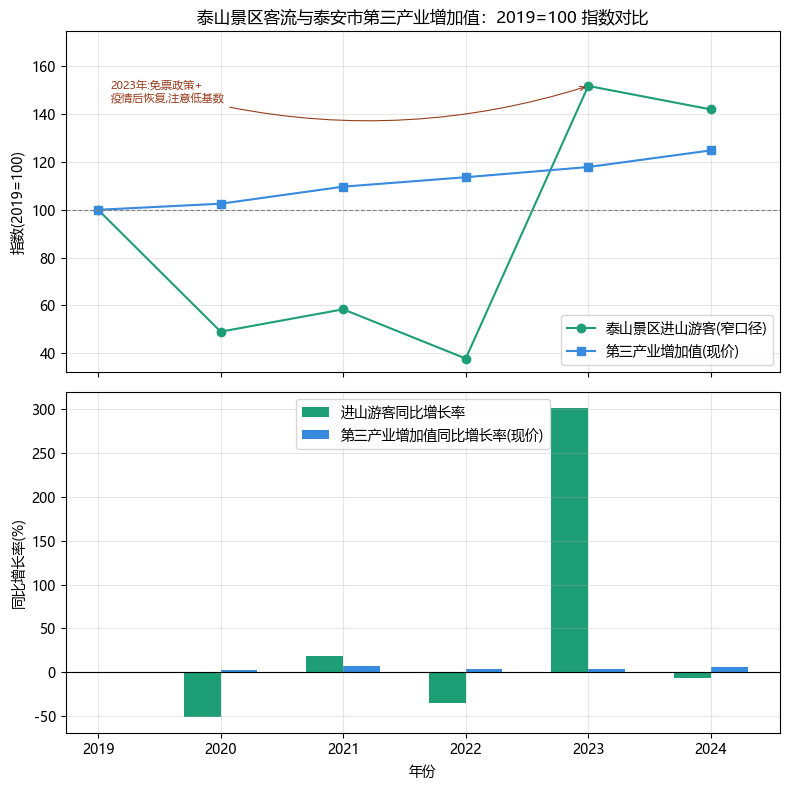

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# 面板1：2019=100 指数对比
ax1.plot(CORE_YEARS, visitors_index, marker='o', label='泰山景区进山游客(窄口径)', color='#1D9E75')
ax1.plot(CORE_YEARS, tertiary_index, marker='s', label='第三产业增加值(现价)', color='#378ADD')
ax1.axhline(100, color='gray', linewidth=0.8, linestyle='--')
ax1.set_ylabel('指数(2019=100)')
ax1.set_title('泰山景区客流与泰安市第三产业增加值：2019=100 指数对比')
ax1.legend()
ax1.grid(alpha=0.3)

# 面板2：年度增长率对比
ax2.bar([y - 0.15 for y in CORE_YEARS], visitors_growth, width=0.3,
        label='进山游客同比增长率', color='#1D9E75')
ax2.bar([y + 0.15 for y in CORE_YEARS], tertiary_growth, width=0.3,
        label='第三产业增加值同比增长率(现价)', color='#378ADD')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('同比增长率(%)')
ax2.set_xlabel('年份')
ax2.legend()
ax2.grid(alpha=0.3)

# 标注2023年：低基数+免票政策，避免图本身"看起来在暗示因果"
ax1.annotate('2023年:免票政策+\n疫情后恢复,注意低基数',
             xy=(2023, visitors_index.loc[2023]), xytext=(2019.1, 145),
             fontsize=8, color='#993C1D', ha='left',
             arrowprops=dict(arrowstyle='->', color='#993C1D', lw=0.8,
                              connectionstyle='arc3,rad=0.15'))
ax1.set_ylim(top=max(visitors_index.max(), tertiary_index.max()) * 1.15)

plt.tight_layout()
plt.show()  # notebook里直接显示图，不用等保存完才能看

## 第六步：保存图片
确认上面图显示正常后，运行这一格把图存成文件。

In [6]:
output_path = '../analysis/figures/01_core_comparison_python.png'  
plt.savefig(output_path, dpi=150)
print(f"图已保存到：{output_path}")

图已保存到：../analysis/figures/01_core_comparison_python.png


<Figure size 640x480 with 0 Axes>